In [17]:
import json
import skimage.io as skio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.path import Path
import itertools as it
from skimage.transform import resize
import os
from tqdm import tqdm
from sklearn.neighbors import kneighbors_graph
import networkx as nx
import ot
from multiprocessing import Pool, cpu_count
from scipy.spatial.distance import cdist, pdist, squareform
import umap as umap
import pickle
import seaborn as sns
from cajal.gw_cython import GW_cell, gw_cython_core
from multiprocessing import Pool, cpu_count

In [2]:
def process_gastoid_images(data_path, dataset_dir, gastr_meta, im_fname_pre, im_fname_suf, n_ds=4):
    image_gastrs = []
    gastr_metadata_list = []

    for i in tqdm(range(len(gastr_meta['annotations']))):
        # load image
        im_phase_path = data_path + dataset_dir + im_fname_pre + gastr_meta['annotations'][i]['location']['XY'] + im_fname_suf
        im_green_path = im_phase_path.replace('Phase', 'Green')
        im_red_path = im_phase_path.replace('Phase', 'Red')
        im_phase = skio.imread(im_phase_path)
        im_phase = resize(im_phase, (im_phase.shape[0] // n_ds, im_phase.shape[1] // n_ds), anti_aliasing=True)
        im_green = skio.imread(im_green_path)
        im_green = resize(im_green, (im_green.shape[0] // n_ds, im_green.shape[1] // n_ds), anti_aliasing=True)
        im_red = skio.imread(im_red_path)
        im_red = resize(im_red, (im_red.shape[0] // n_ds, im_red.shape[1] // n_ds), anti_aliasing=True)
        # rescale outlier pixels
        im_green[im_green > np.quantile(im_green, 0.99)] = np.quantile(im_green, 0.99)
        im_red[im_red > np.quantile(im_red, 0.99)] = np.quantile(im_red, 0.99)
    
        # save metadata
        gastr_meta_i = {'clone':gastr_meta['annotations'][i]['tags'], 
                     'location_XY':[gastr_meta['annotations'][i]['location']['XY']],
                     'location_Z':[gastr_meta['annotations'][i]['location']['Z']],
                     'time':[gastr_meta['annotations'][i]['location']['Time']],
                     'id':[gastr_meta['annotations'][i]['id']],
                     'dataset_id':[gastr_meta['annotations'][i]['datasetId']],
                     'dataset_dir':[dataset_dir], 'im_path':[im_green_path]
                   }
        
        # convert polygon mask to pixel-level mask
        mask_verts = [(pt['x']/n_ds, pt['y']/n_ds) for pt in gastr_meta['annotations'][i]['coordinates']]
        image_pts = np.array(list(it.product(range(im_phase.shape[0]),range(im_phase.shape[0]))))
        is_mask = Path(mask_verts).contains_points(image_pts)
        mask_pts = image_pts[is_mask]
        # skip gastruloid if no mask, or mask too small
        if len(mask_pts) < 5:
            continue

        gastr_metadata_list.append(gastr_meta_i)
    
        # crop image around mask
        x_min = mask_pts[:,0].min()
        x_max = mask_pts[:,0].max()
        y_min = mask_pts[:,1].min()
        y_max = mask_pts[:,1].max()
        # im_crop = im.copy()[y_min:y_max, x_min:x_max]
        im_green_crop = im_green.copy()[y_min:y_max, x_min:x_max]
        im_red_crop = im_red.copy()[y_min:y_max, x_min:x_max]
        im_mask = np.reshape(is_mask, im_phase.shape).T
        im_crop_mask = im_mask[y_min:y_max, x_min:x_max]
    
        # save gastroid info for GW
        gastr_dict = {key: [] for key in ['x', 'y', 'green', 'red']}
        for i in range(im_crop_mask.shape[0]):
            for j in range(im_crop_mask.shape[1]):
                if im_crop_mask[i,j]:
                    gastr_dict['x'].append(i)
                    gastr_dict['y'].append(j)
                    # gastr_dict['green_red'].append(im_crop[i,j])
                    gastr_dict['green'].append(im_green_crop[i,j])
                    gastr_dict['red'].append(im_red_crop[i,j])
        gastr_dict['x'] = np.array(gastr_dict['x'])
        gastr_dict['y'] = np.array(gastr_dict['y'])
        gastr_dict['coords'] = np.stack([gastr_dict['x'], gastr_dict['y']], axis=1)
        gastr_dict['green'] = np.array(gastr_dict['green'])
        gastr_dict['red'] = np.array(gastr_dict['red'])
        image_gastrs.append(gastr_dict)

    return(image_gastrs, gastr_metadata_list)

In [3]:
n_ds = 8
# list of dictionaries containing each gastruloid's pixel coordinate and intensity info
image_gastrs = []
# For saving each images' metadata
gastr_metadata_list = []

In [6]:
data_path = '../../data/raj_lab/gastruloid_imaging/Input Data - May 2024/'

In [7]:
dataset_dir = 'Ewx_eWx_ewX_fixed/'
im_fname_pre = 'Phase_EwxeWxewX_'
im_fname_suf = '_1_00d00h00m.tif'
# read gastruloid metadata and mask info from json file
json_fname = next((fname for fname in os.listdir(data_path + dataset_dir) if '.json' in fname), None)
json_path = data_path + dataset_dir + json_fname
with open(json_path) as json_data:
    gastr_meta = json.load(json_data)
# process gastroid images
temp_image_gastrs, temp_gastr_metadata_list = process_gastoid_images(data_path, dataset_dir, gastr_meta, im_fname_pre, im_fname_suf, n_ds=n_ds)
image_gastrs = image_gastrs + temp_image_gastrs
gastr_metadata_list = gastr_metadata_list + temp_gastr_metadata_list

100%|███████████████████████████████████████████████████████████████████████████████████| 31/31 [00:55<00:00,  1.79s/it]


In [8]:
dataset_dir = 'EX_EW_WX_EWX_fixed/'
im_fname_pre = 'Phase_EXEWWXEWX_'
im_fname_suf = '_1_00d00h00m.tif'
# read gastruloid metadata and mask info from json file
json_fname = next((fname for fname in os.listdir(data_path + dataset_dir) if '.json' in fname), None)
json_path = data_path + dataset_dir + json_fname
with open(json_path) as json_data:
    gastr_meta = json.load(json_data)
# process gastroid images
temp_image_gastrs, temp_gastrRe_metadata_list = process_gastoid_images(data_path, dataset_dir, gastr_meta, im_fname_pre, im_fname_suf, n_ds=n_ds)
image_gastrs = image_gastrs + temp_image_gastrs
gastr_metadata_list = gastr_metadata_list + temp_gastr_metadata_list

100%|███████████████████████████████████████████████████████████████████████████████████| 22/22 [00:39<00:00,  1.80s/it]


In [11]:
# construct metadata table for all images
gastr_metadata = pd.DataFrame(columns = gastr_metadata_list[0].keys())
for i in range(len(gastr_metadata_list)):
    temp = pd.DataFrame(gastr_metadata_list[i])
    gastr_metadata = pd.concat([gastr_metadata, temp])
gastr_metadata = gastr_metadata.reset_index()
gastr_metadata.head()

,index,clone,location_XY,location_Z,time,id,dataset_id,dataset_dir,im_path
0,0,clone A > B & C,B1,0,0,6655dcd640dcff87960b83d8,665494c540dcff879602364c,Ewx_eWx_ewX_fixed/,../../data/raj_lab/gastruloid_imaging/Input Da...
1,0,clone A > B & C,B2,0,0,6655dd6240dcff87960b83db,665494c540dcff879602364c,Ewx_eWx_ewX_fixed/,../../data/raj_lab/gastruloid_imaging/Input Da...
2,0,clone A > B & C,B4,0,0,6655dd9140dcff87960b83de,665494c540dcff879602364c,Ewx_eWx_ewX_fixed/,../../data/raj_lab/gastruloid_imaging/Input Da...
3,0,clone B > A & B,B7,0,0,6655dda340dcff87960b83e1,665494c540dcff879602364c,Ewx_eWx_ewX_fixed/,../../data/raj_lab/gastruloid_imaging/Input Da...
4,0,clone B > A & B,B8,0,0,6655ddae40dcff87960b83e4,665494c540dcff879602364c,Ewx_eWx_ewX_fixed/,../../data/raj_lab/gastruloid_imaging/Input Da...


In [10]:
# rescale pixel intensities for each channel across all gastruloids in dataset
np.array([image_gastrs[i]['green'] for i in range(len(image_gastrs))]).flatten()
full_green_array = [] # store all green channel pixel intensities for all gastruloids
full_red_array = [] # same of red channel
for i in range(len(image_gastrs)):
    full_green_array.extend(image_gastrs[i]['green'].tolist())
    full_red_array.extend(image_gastrs[i]['red'].tolist())
full_green_array = np.array(full_green_array)
full_red_array = np.array(full_green_array)
# save channel mean and std across all gastruloids
green_mean = full_green_array.mean()
red_mean = full_red_array.mean()
green_std = full_green_array.std()
red_std = full_red_array.std()
# rescale pixel intensities in each gastruloid dictionary
for i in range(len(image_gastrs)):
    image_gastrs[i]['green'] = (image_gastrs[i]['green']-green_mean) / green_std
    image_gastrs[i]['red'] = (image_gastrs[i]['red']-red_mean) / red_std

/tmp/ipykernel_5462/2113134430.py:2: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  np.array([image_gastrs[i]['green'] for i in range(len(image_gastrs))]).flatten()


In [13]:
def compute_geodesic_dmat(coords, n_neigh=4):
    # compute NN graph
    knn = kneighbors_graph(coords, n_neigh, mode='connectivity', include_self=False)
    # compute pairwise geodesic distances
    G = nx.from_numpy_matrix(knn.toarray())
    p = nx.shortest_path(G)
    # construct distance matrix
    gastr_dmat = np.zeros((coords.shape[0],coords.shape[0]))
    index_pairs = it.combinations(iter(range(coords.shape[0])), 2)
    for i,j in index_pairs:
        gastr_dmat[i,j] = len(p[i][j])-1
        gastr_dmat[j,i] = len(p[i][j])-1
    return(gastr_dmat)

In [14]:
# compute geodesic distance matrix for each gastruloid
gastr_dmats = []
for i in tqdm(range(len(image_gastrs))):
    dmat = compute_geodesic_dmat(image_gastrs[i]['coords'])
    gastr_dmats.append(dmat)

100%|███████████████████████████████████████████████████████████████████████████████████| 53/53 [00:23<00:00,  2.28it/s]


In [18]:
def _init_fgw_pool(cell_dmats: list, cell_dists: list, channels: str):
    global _CELL_DMATS #
    _CELL_DMATS = cell_dmats # list of intragastruloid distance matricies
    global _CELL_DISTS
    _CELL_DISTS = cell_dists # list of dictionaries storing gastruloid channel intensities
    global _CHANNELS
    _CHANNELS = channels # which channels to use for fused cost

# compute fGW from one gastruloid to another 
def _fgw_index(p: tuple[int, int]):
    i, j = p
    A = _CELL_DMATS[i]
    B = _CELL_DMATS[j]
    n_A = A.shape[0]
    n_B = B.shape[0]
    # uniform probability distributions
    a = np.repeat(1/n_A, n_A)
    b = np.repeat(1/n_B, n_B)

    # fGW computation
    alpha = 0.5
    cost_matrix = cdist(np.stack([_CELL_DISTS[i][channel] for channel in _CHANNELS], axis=1), 
                        np.stack([_CELL_DISTS[j][channel] for channel in _CHANNELS], axis=1),)
    coupling_mat_morph, log = ot.gromov.fused_gromov_wasserstein(M=cost_matrix, C1=A, C2=B, p=a, q=b, alpha=alpha, log=True)
    gw_dist_morph = log['fgw_dist']

    return (i, j, gw_dist_morph) 

In [20]:
N = len(gastr_dmats)
num_processes = cpu_count()
chunksize = 1
# compute pairwise fGW distances between all gastruloids
index_pairs = it.combinations(iter(range(N)), 2) # gastruloid pairs to compute fGW / OT for
total_num_pairs = int((N * (N - 1)) / 2) # total number of gastruloid pairs to compute (for progress bar)
with Pool(
    initializer=_init_fgw_pool, initargs=(gastr_dmats,image_gastrs,['green','red']), processes=num_processes
) as pool:
    res = pool.imap_unordered(_fgw_index, index_pairs, chunksize=chunksize)
    # store GW distances
    fgw_dmat = np.zeros((N,N))
    for i, j, fgw_dist in tqdm(res, total=total_num_pairs, position=0, leave=True):
        fgw_dmat[i,j] = fgw_dist
        fgw_dmat[j,i] = fgw_dist

100%|███████████████████████████████████████████████████████████████████████████████| 1378/1378 [24:20<00:00,  1.06s/it]


/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1780: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


<AxesSubplot: xlabel='UMAP_1', ylabel='UMAP_2'>

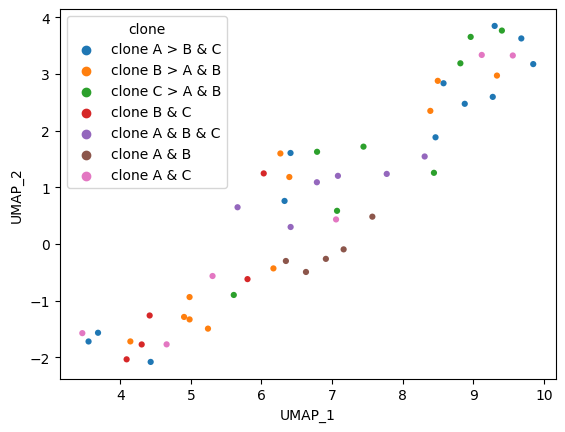

In [25]:
# visualizing GW space
reducer = umap.UMAP(n_components=2, metric="precomputed", random_state=1)
umap_coords = reducer.fit_transform(fgw_dmat)
plot_df = gastr_metadata.copy()
plot_df['UMAP_1'] = umap_coords[:,0]
plot_df['UMAP_2'] = umap_coords[:,1]
plot_df['gastruloid'] = plot_df.index
sns.scatterplot(data=plot_df, x="UMAP_1", y="UMAP_2", hue="clone", linewidth=0, s=20)